## License

This notebook is a conversion of a Sentinel Hub evalscript and is licensed under
**CC-BY-SA-4.0**.

Original evalscript: https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-1/urban_areas/  
Source: Sentinel Hub Custom Scripts (CC-BY-SA-4.0)  
Conversion: Development Seed (openEO-UDP project)  

# Visualizing Urban Areas

This notebook demonstrates how to locate urban areas and individual buildings using Sentinel‑1 GRD VH and VV polarizations. VH and VV backscatter are mapped to RGB so that different building types appear in distinctive colors: VV is shown in the green channel, VH in the blue channel, and only strongly reflecting VH values (VH > 0.5) are added to the red channel. As a result, buildings appear purple (dominated by VH), green (dominated by VV), or white (strong in both), which helps separate them from surrounding terrain and supports tasks such as tracking urban expansion, estimating building types, or identifying buildings at risks of natural disturbances (e.g. flood). The method performs less reliably in high‑elevation regions, where snow and steep slopes can also appear bright in VH and VV, and make urban areas harder to distinguish.

## Overview

In this notebook, we will:
1. Connect to an openEO backend service
2. Define an area of interest containing terrestrial land
3. Load Sentinel-1 GRD imagery for a specific date, using VH and VV polarizations
4. Define the RGB composite:
    - VV is placed in the green channel
    - VH is placed in the blue channel
    - Only high VH values (VH > 0.5) are added to the red channel
5. Visualize buildings and urban areas, which appear purple (strong VH), green (strong VV), or white (strong in both)

## Import Required Libraries

We begin by importing the necessary Python libraries for data processing,
visualization, and parameter management.

In [84]:
import matplotlib.pyplot as plt
from PIL import Image
from openeo.processes import array_create, if_, log

from openeo_udp import ParameterManager

## Load Parameters and Connect to openEO Backend

Load algorithm parameters from the co-located parameter file and connect to an
openEO backend. We use the **Copernicus Data Space Ecosystem (CDSE)** as the
primary endpoint for Sentinel-1 GRD data.

In [85]:
_algorithm_id = "urban_areas"

param_manager = ParameterManager("urban_areas.params.py")
param_manager.print_options("urban areas algorithm")

Available parameter sets for urban areas algorithm:
  1. bologna_italy: Bologna, Italy
  2. paris_france: Paris, France
  3. dubai_uae: Dubai, UAE

Available OpenEO endpoints:
  1. eopf_explorer: https://api.explorer.eopf.copernicus.eu/openeo
  2. copernicus_dataspace: https://openeo.dataspace.copernicus.eu/
  3. ds_development: https://openeo.ds.io/
  4. localhost_dev: http://localhost:8082/

💡 Tip: Use param_manager.interactive_parameter_selection() for interactive selection,
or param_manager.quick_connect('set_name', 'endpoint') for direct connection.
To change selections, use the interactive widgets in the next cell.


In [86]:
connection, current_params = param_manager.quick_connect(
    param_set="bologna_italy",
    endpoint="ds_development",
)

🔄 Connecting to ds_development...
📍 Using parameter set: bologna_italy
✅ Successfully connected to ds_development
✅ Parameters loaded and mapped for: Bologna, Italy
🔄 Parameters mapped for endpoint ds_development:


## Load Sentinel-1 Data

Sentinel-1 imagery is provided by two polar-orbiting satellites, operating day and night
performing C-band synthetic aperture radar imaging that enables image acquisition regardless
of the weather. Its applications include monitoring sea ice, oil spills, land-use change,
among others ([Sentinel Hub documentation](https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel/sentinel-1/)).

`time` and `bounding_box` are passed as **`Parameter` objects** so the exported process
graph keeps `{"from_parameter": ...}` references and remains reusable as a UDP.
The time dimension is then reduced to the first available acquisition.

In [87]:
s1cube = connection.load_collection(
    current_params["collection"].default,
    temporal_extent=current_params["time"],
    spatial_extent=current_params["bounding_box"],
    bands=current_params["bands"].default,
)

# Reduce the time dimension to pick the first available acquisition.
s1cube = s1cube.reduce_dimension(
    dimension=current_params["time_dimension"],
    reducer="first",
)

print("✅ Sentinel-1 data loaded successfully!")

✅ Sentinel-1 data loaded successfully!


In [88]:
def urban_viz(data):
    VH, VV = (data[0], data[1])
    
    # convert to dB
    VHdb = 10 * log(VH, 10)
    VVdb = 10 * log(VV, 10)

    red_output = if_(VHdb > 22, 31.0, 17.0)  # white above threshold, black below
    green_output = VVdb
    blue_output = VHdb + 19.03

    output = array_create([
        red_output,
        green_output,
        blue_output
    ])

    return output

In [89]:
urban_image = s1cube.apply_dimension(
    dimension=current_params["bands_dimension"],
    process=urban_viz,
)

urban_image = urban_image.linear_scale_range(
    input_min=17, input_max=31, output_min=0, output_max=255
)

urban_image = urban_image.save_result("PNG")

In [90]:
filename = (
    f"{_algorithm_id}_"
    f"{current_params['location_name'].replace(' ', '_').replace(',', '').lower()}.png"
)

resolved = param_manager.resolve(urban_image, current_params)
resolved.download(filename)

## Visualize the Result

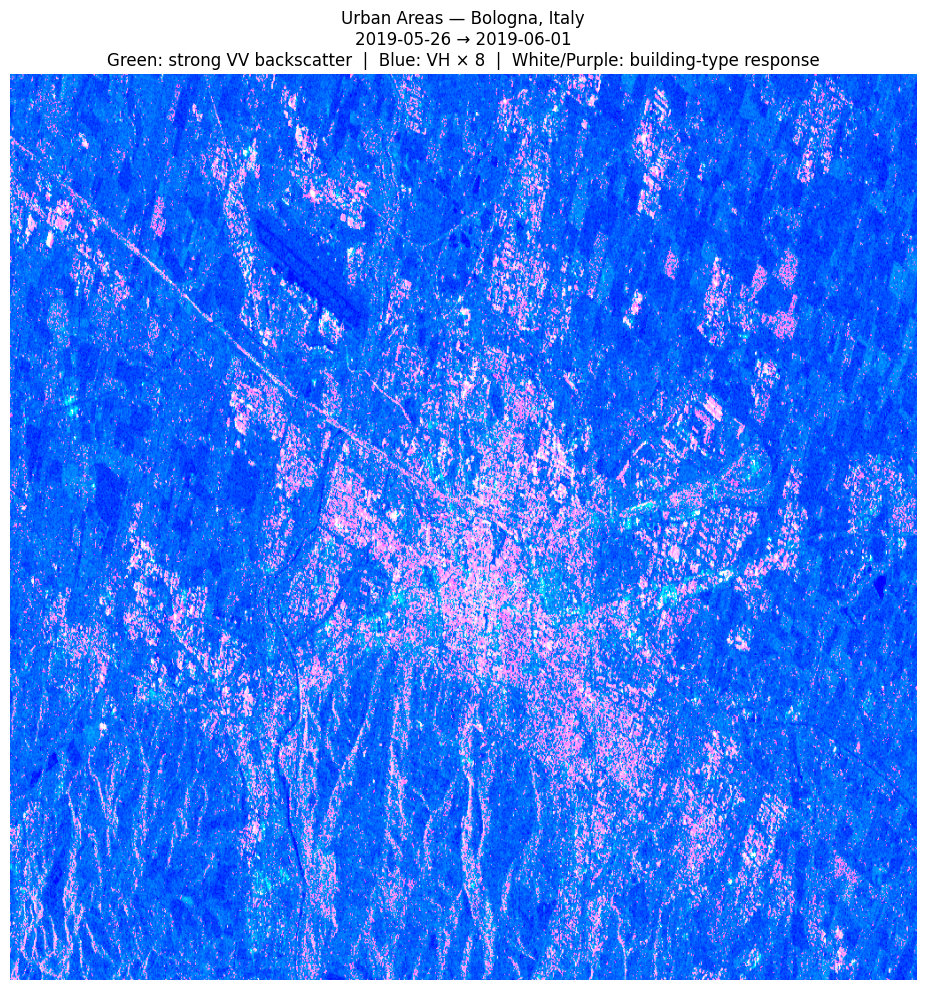

In [91]:
img = Image.open(filename)

fig, ax = plt.subplots(figsize=(14, 10), dpi=100)
ax.imshow(img)
ax.set_title(
    f"Urban Areas — {current_params['location_name']}\n"
    f"{current_params['time'].default[0]} → {current_params['time'].default[1]}\n"
    "Green: strong VV backscatter  |  Blue: VH × 8  |  White/Purple: building-type response",
    fontsize=12,
)
ax.axis("off")
plt.tight_layout()
plt.show()

## Attribution

This openEO User-Defined Process is a conversion of the original Sentinel Hub evalscript:

**Original Script:** [Urban Areas Script](https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-1/urban_areas/)

**Author:** Monja B. Šebela

**Source Repository:** [Sentinel Hub Custom Scripts](https://github.com/sentinel-hub/custom-scripts)

This conversion maintains the scientific methodology and visualization approach of the original evalscript while adapting it to the openEO process graph framework for interoperability across openEO-compliant backends.

## Conclusion

This notebook demonstrates the implementation of Urban Area estimation for mapping buildings using openEO and Sentinel-1 imagery. The notebook succesfully:

- Identifies urban areas using VV and VH polarizations
- Produces color-mapped visualizations

The approach can be extended to:

- Create time-series animations to track urban area changes
- Integrate the outputs into early-warning systems from natural disturbances
- Support modelling of the spread and intensity of natural disturbances under varying climate conditions that would affect cities